## GET IN FAST API

In [ ]:
from fastapi import FastAPI

app=FastAPI()

@app.get("/")
def root():
    return {"message":"Hii welcome to the site "}

@app.get("/posts/{post_id}")
def get_post(post_id:int):
    return {
        "message":"Getting Post",
        "post_id":post_id}



# POST IN FAST API

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app=FastAPI()

class Post(BaseModel):
    movie_name:str
    rating:float

class User(BaseModel):
    name:str
    email:str
    age:int

@app.post("/post/user")
def add_user(user:User):
    return{
        "message":"user created",
        "user": user
    }

@app.post("/post/{post_id}")
def create_post(post_id : int , post:Post):
    return {
        "post_id":post_id,
        "metadata":post
    }

@app.get("/post/{post_id}")
def get_id(post_id:int):
    return{"post_id":post_id}

# RESPONSE MODEL

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

app=FastAPI()

class PostResponse(BaseModel):
    post_id:int
    movie_name:str
    rating:float

@app.get("/post/{post_id}" , response_model=PostResponse)
def get_post(post_id:int):
    return{
        "post_id": post_id,
        "movie_name": "Interstellar",
        "rating": 9.5
    }

# CRUD OPERATIONS

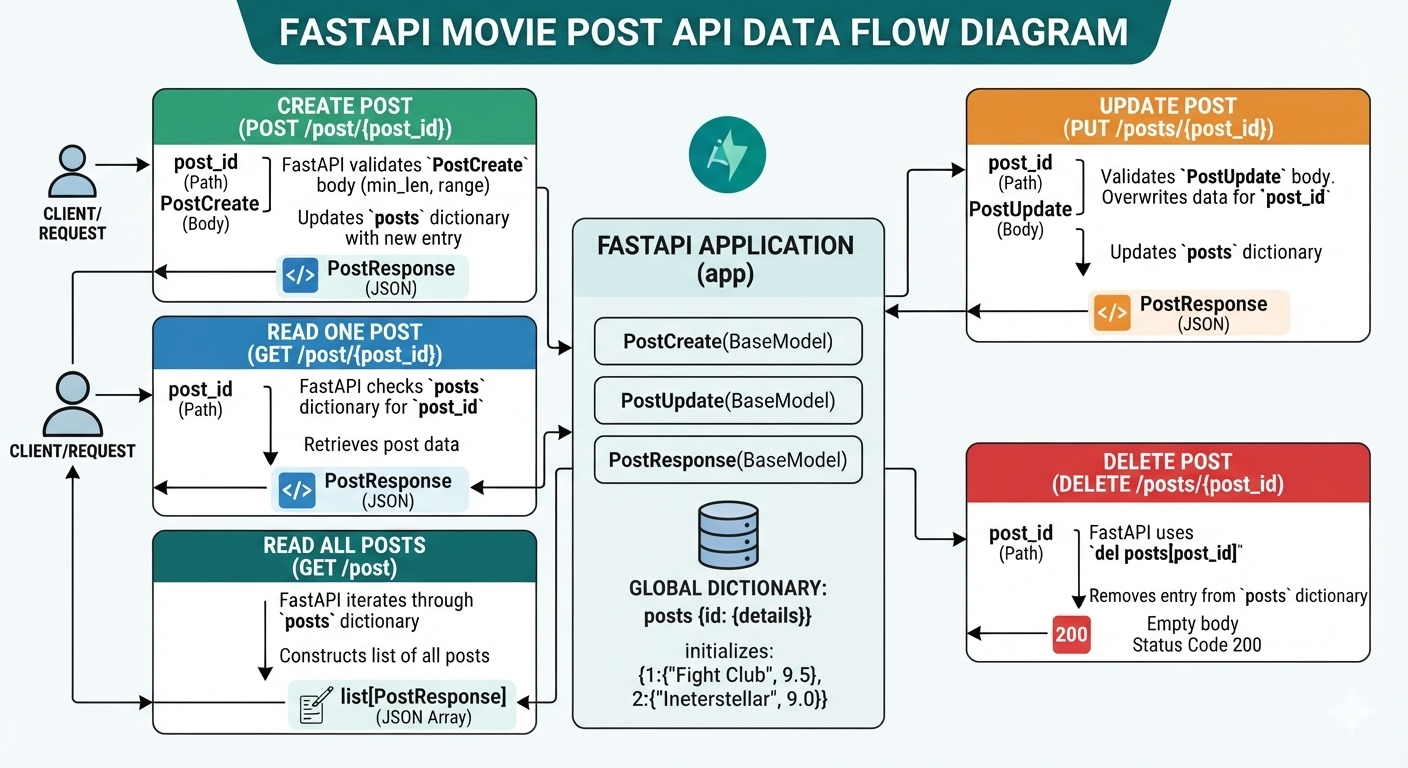

In [ ]:
from fastapi import FastAPI , status
from pydantic import BaseModel , Field

app=FastAPI()

class PostCreate(BaseModel):
    movie_name:str=Field(min_length=2 , max_length=100)
    rating:float=Field(ge=0 , le=10)

class PostUpdate(BaseModel):
    movie_name:str=Field(min_length=2 , max_length=100)
    rating: float=Field(ge=0 , le=10)

class PostResponse(BaseModel):
    post_id:int
    movie_name:str
    rating:float



posts={
    1:{"movie_name":"Fight Club" , "rating":9.5},
    2:{"movie_name":"Ineterstellar" , "rating": 9.0}
}

#! Create 

@app.post("/post/{post_id}" , response_model=PostResponse)
def create_post(post_id:int , post:PostCreate):
    posts[post_id]={
        "movie_name":post.movie_name,
        "rating":post.rating
    }

    return{
        "post_id":post_id,
        "movie_name":post.movie_name,
        "rating":post.rating
    }



#! READ ONE

@app.get("/post/{post_id}" , response_model=PostResponse)
def get_posts(post_id:int):
    post=posts[post_id]

    return{
        "post_id":post_id,
        "movie_name": post["movie_name"],
        "rating": post["rating"]
    }


#! UPDATE

@app.put(
    "/posts/{post_id}",
    response_model=PostResponse
)
def update_post(post_id: int, post: PostUpdate):

    posts[post_id] = {
        "movie_name": post.movie_name,
        "rating": post.rating
    }

    return {
        "post_id": post_id,
        "movie_name": post.movie_name,
        "rating": post.rating
    }


#! DELETE 

@app.delete("/posts/{post_id}")
def delete_post(post_id: int):

    del posts[post_id]



#! READ ALL 

@app.get("/post" , response_model=list[PostResponse])
def get_all_posts():
    result=[]

    for post_id , post in posts.items():
        result.append({
            "post_id":post_id,
            "movie_name":post['movie_name'],
            "rating":post["rating"]
        })

    return result